In [1349]:
# %pip install plotly
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px

In [1350]:
s = pd.Series([10,20,30,40,50])
s
s[2:4]
s.iloc[[3,4]]
s. name = 'calories'
index = ["apple", "banana", "grapes", "orange", "strawberry"]
s.index = index
s

apple         10
banana        20
grapes        30
orange        40
strawberry    50
Name: calories, dtype: int64

In [1351]:
s.loc['apple': 'orange']

apple     10
banana    20
grapes    30
orange    40
Name: calories, dtype: int64

In [1352]:
s.iloc[0:4:2]

apple     10
grapes    30
Name: calories, dtype: int64

In [1353]:
fruit_protein = {
"Avocado": 2.0,
"Guava": 2.6,
"Blackberries": 2.0,
"Oranges": 0.9,
"Banana": 1.1,
"Apples": 0.3,
"Kiwi": 1.1,
"Pomegranate": 1.7,
"Mango": 0.8,
"Cherries": 1.0
}
s2 = pd.Series(fruit_protein, name = 'Protain')
s2

Avocado         2.0
Guava           2.6
Blackberries    2.0
Oranges         0.9
Banana          1.1
Apples          0.3
Kiwi            1.1
Pomegranate     1.7
Mango           0.8
Cherries        1.0
Name: Protain, dtype: float64

In [1354]:
s2.iloc[[0,4]]

Avocado    2.0
Banana     1.1
Name: Protain, dtype: float64

In [1355]:

s2[s2 <2]
s2[(s2 > 1) & (s2 <=2)]
s2['Mango'] = 2.8
s2

Avocado         2.0
Guava           2.6
Blackberries    2.0
Oranges         0.9
Banana          1.1
Apples          0.3
Kiwi            1.1
Pomegranate     1.7
Mango           2.8
Cherries        1.0
Name: Protain, dtype: float64

In [1356]:
ser = pd.Series(['a', np.nan, 1, np.nan, np.nan])
ser.notnull().sum()
ser.isnull().sum()

np.int64(3)

In [1357]:
# DataFrame
data ={
"Name":["Alice", "Bob", "Charlie", "David", "Eve", "Alice"],
"Age": [25, 30, 35, np.nan, 29, 25],
"Department": ["HR", "IT", "Finance", "IT", "HR", "HR"],
"Salary": [50000, 60000, 70000, 62000, np.nan, 50000]
}

df = pd.DataFrame(data)
df.iloc[1:3]
df.loc[1:3,['Age','Department']]
df.iloc[1:4, :2]

,Name,Age
1,Bob,30.0
2,Charlie,35.0
3,David,NaN


In [1358]:
df[['Age', 'Department']]
df.drop('Age', axis=1)
df.shape

(6, 4)

In [1359]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        6 non-null      object 
 1   Age         5 non-null      float64
 2   Department  6 non-null      object 
 3   Salary      5 non-null      float64
dtypes: float64(2), object(2)
memory usage: 324.0+ bytes


,Age,Salary
count,5.000000,5.000000
mean,28.800000,58400.000000
std,4.147288,8532.291603
min,25.000000,50000.000000
25%,25.000000,50000.000000
50%,29.000000,60000.000000
75%,30.000000,62000.000000
max,35.000000,70000.000000


In [1360]:
df['Salary'] = df['Salary'] + 5000
df.rename(columns={'Department': 'Dept'}, inplace=True)
df

,Name,Age,Dept,Salary
0,Alice,25.0,HR,55000.0
1,Bob,30.0,IT,65000.0
2,Charlie,35.0,Finance,75000.0
3,David,NaN,IT,67000.0
4,Eve,29.0,HR,NaN
5,Alice,25.0,HR,55000.0


In [1361]:
df['Salary'].unique()
df['Dept'].unique()
df['Dept'].value_counts()
df['Promoted Salary'] = df['Salary'] *10
df

,Name,Age,Dept,Salary,Promoted Salary
0,Alice,25.0,HR,55000.0,550000.0
1,Bob,30.0,IT,65000.0,650000.0
2,Charlie,35.0,Finance,75000.0,750000.0
3,David,NaN,IT,67000.0,670000.0
4,Eve,29.0,HR,NaN,NaN
5,Alice,25.0,HR,55000.0,550000.0


In [1362]:
df.isnull().sum()
df.dropna(how='all')


,Name,Age,Dept,Salary,Promoted Salary
0,Alice,25.0,HR,55000.0,550000.0
1,Bob,30.0,IT,65000.0,650000.0
2,Charlie,35.0,Finance,75000.0,750000.0
3,David,NaN,IT,67000.0,670000.0
4,Eve,29.0,HR,NaN,NaN
5,Alice,25.0,HR,55000.0,550000.0


In [1363]:
df['Age'].fillna(df['Age'].mean())
df['Salary'].fillna(df['Salary'].median())
df['Age'].bfill()

0    25.0
1    30.0
2    35.0
3    29.0
4    29.0
5    25.0
Name: Age, dtype: float64

In [1364]:

df['Name'] = df['Name'].replace('Charlie', 'Rose')
df_dup = df[df.duplicated(keep='last')]
df_dup
df = df.drop_duplicates()
df

,Name,Age,Dept,Salary,Promoted Salary
0,Alice,25.0,HR,55000.0,550000.0
1,Bob,30.0,IT,65000.0,650000.0
2,Rose,35.0,Finance,75000.0,750000.0
3,David,NaN,IT,67000.0,670000.0
4,Eve,29.0,HR,NaN,NaN


In [1365]:
df.loc[:,'Promoted Salary'] = df.loc[:,'Promoted Salary'].apply(lambda x: x/10 if x > 65000 else x)
df

,Name,Age,Dept,Salary,Promoted Salary
0,Alice,25.0,HR,55000.0,55000.0
1,Bob,30.0,IT,65000.0,65000.0
2,Rose,35.0,Finance,75000.0,75000.0
3,David,NaN,IT,67000.0,67000.0
4,Eve,29.0,HR,NaN,NaN


In [1366]:
df.loc[:,'Age'] = df.loc[:,'Age'].apply(lambda x: x/2)
df

,Name,Age,Dept,Salary,Promoted Salary
0,Alice,12.5,HR,55000.0,55000.0
1,Bob,15.0,IT,65000.0,65000.0
2,Rose,17.5,Finance,75000.0,75000.0
3,David,NaN,IT,67000.0,67000.0
4,Eve,14.5,HR,NaN,NaN


In [1367]:
department_info = {
"Dept": ["HR", "IT", "Finance"],
"Location": ["New York", "San Francisco", "Chicago"],
"Manager": ["Laura", "Steve", "Nina"]}

df2 = pd.DataFrame(department_info)
pd.merge(df, df2, on = 'Dept')

,Name,Age,Dept,Salary,Promoted Salary,Location,Manager
0,Alice,12.5,HR,55000.0,55000.0,New York,Laura
1,Bob,15.0,IT,65000.0,65000.0,San Francisco,Steve
2,Rose,17.5,Finance,75000.0,75000.0,Chicago,Nina
3,David,NaN,IT,67000.0,67000.0,San Francisco,Steve
4,Eve,14.5,HR,NaN,NaN,New York,Laura


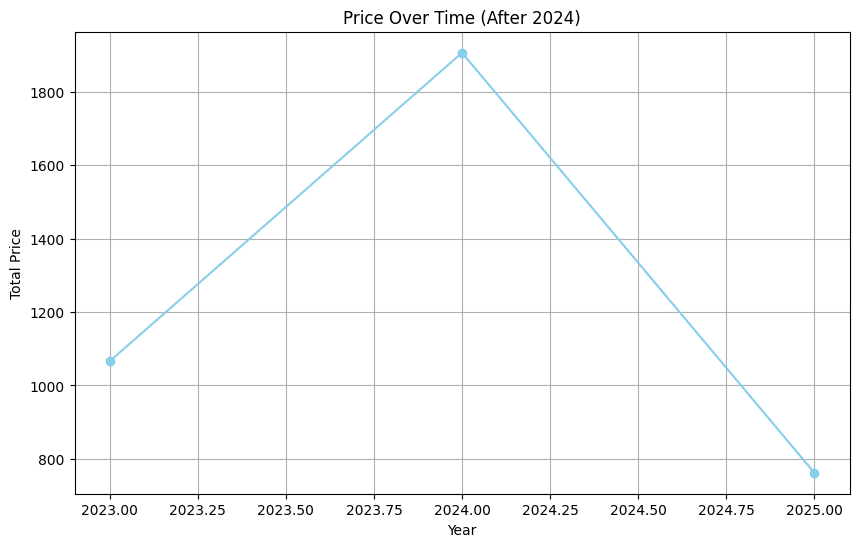

,order_id,customer_id,customer_name,customer_email,product_id,product_name,category,brand,price,quantity,total_amount,discount_percent,order_date,shipping_address,city,state,country,payment_method,order_status,customer_age
0,ORD-1543,CUST-0225,Ashley Lewis,ashley.lewis@email.com,PROD-5566,Business Strategy,Books,O'Reilly,19.87,2,39.74,20.0,2023-11-11,8944 Second Ave,New York,NY,Germany,PayPal,Completed,70.0
1,ORD-1260,CUST-0293,Angela Lee,angela.lee@email.com,PROD-5706,Dell Laptop,Electronics,HP,882.75,3,2648.25,20.0,2025-02-19,8232 Second Ave,Jacksonville,FL,Canada,Debit Card,Cancelled,74.0
2,ORD-1044,CUST-0299,David Davis,david.davis@email.com,PROD-8623,Web Development,Books,McGraw-Hill,73.08,5,365.40,15.0,2024-05-10,7584 Park Rd,San Jose,CA,Australia,PayPal,Cancelled,24.0
3,ORD-2011,CUST-0177,Paul Thompson,paul.thompson@email.com,PROD-3154,Dumbbell Set,Sports,Nike,49.62,5,248.10,10.0,2024-11-22,8955 First St,Chicago,IL,Canada,Bank Transfer,Processing,74.0
4,ORD-1755,CUST-0011,James Harris,james.harris@email.com,PROD-8882,Tennis Racket,Sports,Under Armour,74.16,1,74.16,25.0,2024-07-31,6685 Elm St,Dallas,TX,UK,Apple Pay,Processing,24.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1215,ORD-2045,CUST-0202,Lisa Taylor,lisa.taylor@email.com,PROD-5920,Jacket,Clothing,Adidas,199.45,4,797.80,10.0,2023-10-09,6280 Elm St,New York,NY,Australia,PayPal,Shipped,22.0
1216,ORD-2096,CUST-0191,Anthony Martinez,anthony.martinez@email.com,PROD-5204,Vacuum Cleaner,Home & Garden,Cuisinart,113.35,5,566.75,5.0,2024-07-16,6623 Main St,Phoenix,AZ,USA,Debit Card,Processing,29.0
1217,ORD-2131,CUST-0183,Mark Ramirez,mark.ramirez@email.com,PROD-5633,Bed Sheets,Home & Garden,KitchenAid,297.50,3,892.50,15.0,2025-03-14,3664 Second Ave,San Antonio,TX,USA,Apple Pay,Cancelled,71.0
1218,ORD-1861,CUST-0140,Daniel Jones,daniel.jones@email.com,PROD-7964,Bed Sheets,Home & Garden,Cuisinart,61.17,1,61.17,0.0,2023-12-17,7943 Park Rd,Indianapolis,IN,UK,PayPal,Cancelled,55.0


In [1368]:
df4= pd.read_csv('../../Datasets/fromclass/ecommerce_sales_data.csv')

df4['order_date'] = pd.to_datetime(df4['order_date'])


a = df4.groupby(df4['order_date'].dt.year)['quantity'].sum()

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(a.index, a.values, marker='o', color='skyblue')

ax.set_xlabel('Year')
ax.set_ylabel('Total Price')
ax.set_title('Price Over Time (After 2024)')
ax.grid(True)

plt.show()
df4


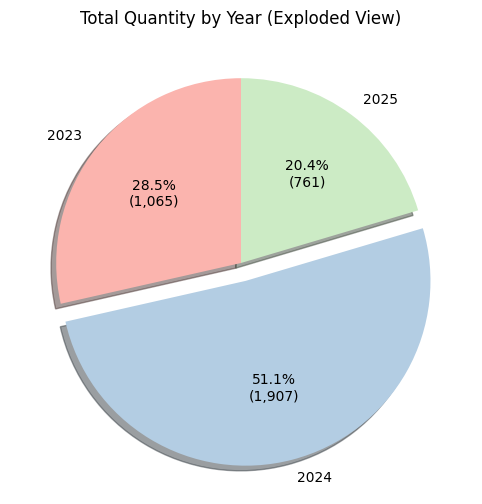

order_date
2023    1066
2024    1907
2025     762
Name: quantity, dtype: int64

In [1369]:
df4 = pd.read_csv('../../Datasets/fromclass/ecommerce_sales_data.csv')
df4['order_date'] = pd.to_datetime(df4['order_date'])

a = df4.groupby(df4['order_date'].dt.year)['quantity'].sum()



fig, ax = plt.subplots(figsize=(10,6))
ax.pie(
    a.values,
    labels=a.index,
    autopct=lambda p: f'{p:.1f}%\n({int(p * sum(a.values) / 100):,})', 
    startangle=90,
    explode=[0, 0.1, 0],          
    colors=plt.cm.Pastel1.colors,
    shadow=True
)
ax.set_title('Total Quantity by Year (Exploded View)')
plt.show()
a

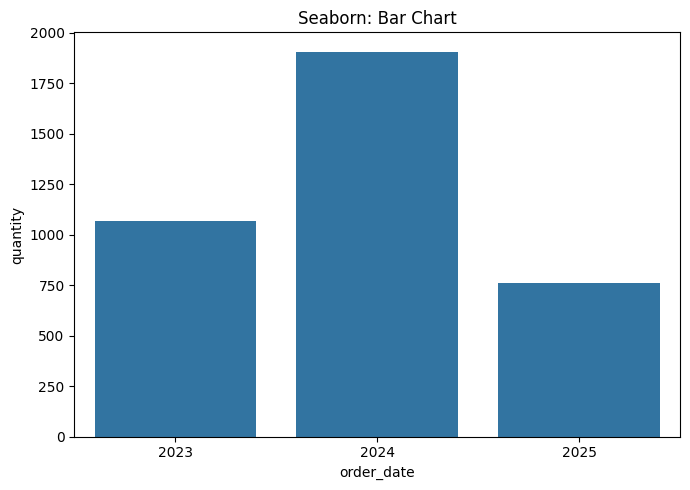

In [1388]:
data = pd.DataFrame(a).reset_index()

fig, axes = plt.subplots( figsize=(7,5))

sns.barplot(x='order_date', y='quantity', data=data, )
axes.set_title('Seaborn: Bar Chart')
axes.set_xlabel('order_date')
axes.set_ylabel('quantity')

plt.tight_layout()
plt.show()


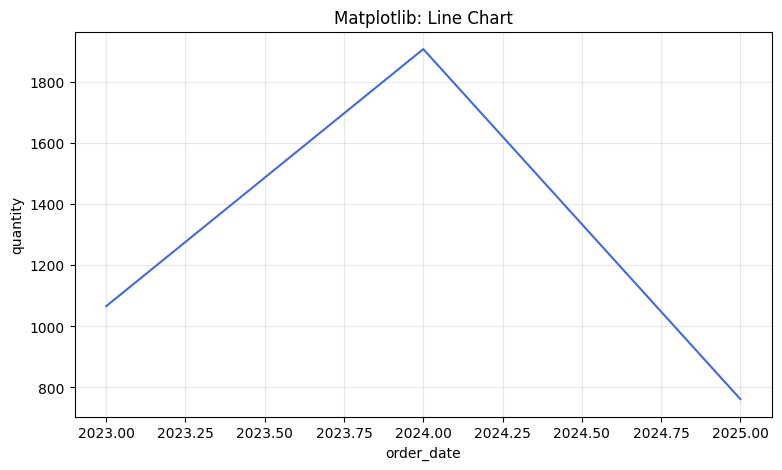

In [1387]:
fig, axes = plt.subplots(figsize=(9,5))

axes.plot(data['order_date'], data['quantity'], color='royalblue')
axes.set_title('Matplotlib: Line Chart')
axes.set_xlabel('order_date')
axes.set_ylabel('quantity')
axes.grid(True, alpha=0.3)
